# Análise de um E-commerce

## Descrição do Problema de Negócio

Um marketplace brasileiro deseja entender melhor:

- evolução das vendas
- categorias mais vendidas
- comportamento dos clientes
- regiões com maior volume de pedidos

Essas informações ajudam nas decisões de marketing, logística e expansão.

## 1. Importação das bibliotecas

Nesta etapa importamos as principais bibliotecas utilizadas em análise de dados com Python.

- **Pandas**: biblioteca fundamental para manipulação e análise de dados estruturados.
- **Numpy**: utilizada para cálculos numéricos e operações matemáticas eficientes.
- **Matplotlib**: biblioteca para criação de gráficos.
- **Seaborn**: biblioteca baseada no Matplotlib que facilita a criação de visualizações estatísticas mais bonitas e informativas.

Essas ferramentas formam a base do ecossistema de análise de dados em Python.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Carregamento dos datasets

Nesta etapa carregamos os arquivos CSV que contêm os dados do marketplace.

Cada arquivo representa uma parte diferente da operação do e-commerce:

- **orders**: informações sobre os pedidos realizados
- **order_items**: produtos comprados em cada pedido
- **products**: informações sobre os produtos
- **customers**: dados dos clientes
- **payments**: formas de pagamento utilizadas

Separar os dados em várias tabelas é comum em bancos de dados relacionais.
Posteriormente será necessário realizar junções (joins) entre essas tabelas para realizar análises mais completas.

In [31]:
orders = pd.read_csv("/content/sample_data/olist_orders_dataset.csv")
order_items = pd.read_csv("/content/sample_data/olist_order_items_dataset.csv")
products = pd.read_csv("/content/sample_data/olist_products_dataset.csv")
customers = pd.read_csv("/content/sample_data/olist_customers_dataset.csv")
payments = pd.read_csv("/content/sample_data/olist_order_payments_dataset.csv")

## 3. Exploração inicial dos dados

Antes de iniciar qualquer análise, é importante entender a estrutura do dataset.

Nesta etapa verificamos:

- primeiras linhas do dataset
- tipos de dados de cada coluna
- possíveis valores nulos

Esse processo é conhecido como **Exploratory Data Analysis (EDA)**.
Ele ajuda a identificar problemas de qualidade nos dados e entender melhor a estrutura das informações.

In [32]:
orders.head()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [33]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

## 4. Preparação e transformação dos dados

Datas geralmente são carregadas como texto quando importamos arquivos CSV.

Para realizar análises temporais (como vendas por mês ou por ano),
precisamos converter essas colunas para o formato de data do Python.

Após essa conversão, podemos extrair informações como:

- mês
- ano
- dia da semana
- trimestre

In [34]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [35]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

## 5. Evolução das vendas ao longo do tempo

Nesta etapa analisamos como o número de pedidos evoluiu ao longo do tempo.

Esse tipo de análise ajuda a identificar:

- crescimento do negócio
- sazonalidade
- impacto de eventos ou campanhas

Agrupamos os pedidos por mês e contamos quantos pedidos ocorreram em cada período.

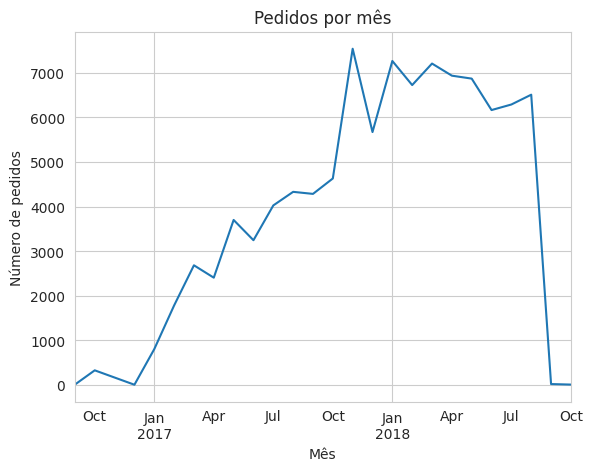

In [36]:
sales_month = orders.groupby("month").size()

plt.figure()

sales_month.plot()

plt.title("Pedidos por mês")
plt.xlabel("Mês")
plt.ylabel("Número de pedidos")

plt.show()

## 6. Ticket médio

O ticket médio representa o valor médio gasto por pedido.

Essa é uma das métricas mais importantes no comércio eletrônico,
pois indica o comportamento de compra dos clientes.

Para calcular essa métrica:

1. somamos o valor dos produtos em cada pedido
2. calculamos a média desses valores

In [37]:
order_value = order_items.groupby("order_id")["price"].sum()

In [38]:
avg_ticket = order_value.mean()

print("Ticket médio:", round(avg_ticket,2))

Ticket médio: 137.75


## 7. Categorias mais vendidas

Nesta etapa buscamos entender quais tipos de produtos são mais populares.

Para isso precisamos unir duas tabelas:

- **order_items** (produtos vendidos)
- **products** (categoria do produto)

Essa junção permite analisar o volume de vendas por categoria.

In [39]:
df = order_items.merge(products, on="product_id")

In [40]:
top_categories = df['product_category_name'].value_counts().head(10)

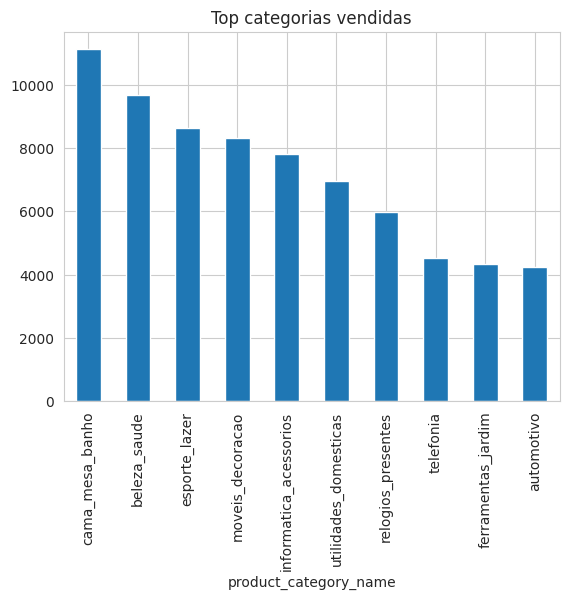

In [41]:
plt.figure()

top_categories.plot(kind="bar")

plt.title("Top categorias vendidas")

plt.show()

## 8. Distribuição geográfica dos clientes

Nesta análise investigamos de quais estados vêm os clientes do marketplace.

Esse tipo de informação é útil para:

- planejamento logístico
- campanhas regionais
- expansão de centros de distribuição

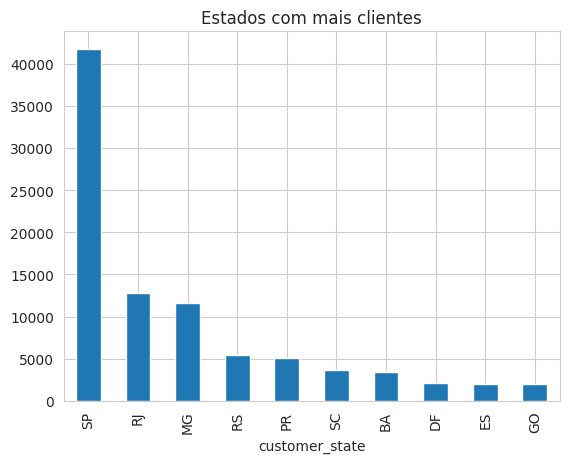

In [42]:
customers_state = customers["customer_state"].value_counts().head(10)

plt.figure()

customers_state.plot(kind="bar")

plt.title("Estados com mais clientes")

plt.show()

## 9. Tempo médio de entrega

O tempo de entrega é um fator crítico na experiência do cliente.

Nesta etapa calculamos a diferença entre:

- data de compra
- data de entrega

Isso nos permite medir o desempenho logístico da operação.

In [43]:
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

delivery_time = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

print("Tempo médio de entrega:", round(delivery_time.mean(),1), "dias")

Tempo médio de entrega: 12.1 dias


## 10. Conclusão

Com base nas análises realizadas, foi possível identificar:

- crescimento das vendas ao longo do tempo
- categorias com maior volume de pedidos
- regiões com maior concentração de clientes
- tempo médio de entrega da operação

Esses insights podem apoiar decisões estratégicas em marketing,
logística e gestão de produtos.